# Home task: CNN - Happy House

## Import libraries

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path
import random

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display
from tensorflow.keras.layers import (
    Input,
    Dense,
    Activation,
    ZeroPadding2D,
    BatchNormalization,
    Flatten,
    Conv2D,
    MaxPooling2D,
)
from tensorflow.keras.models import Model

## Basic configuration

In [19]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("data")
IMAGES_DIR = Path("images")

TRAIN_PATH = DATA_DIR / "train_happy.h5"
TEST_PATH = DATA_DIR / "test_happy.h5"
HOUSE_IMAGE_PATH = IMAGES_DIR / "house_members.png"

print("Train path exists:", TRAIN_PATH.exists())
print("Test path exists:", TEST_PATH.exists())
print("House image exists:", HOUSE_IMAGE_PATH.exists())

Train path exists: True
Test path exists: True
House image exists: True


## Load the data

In [3]:
def load_dataset(train_path, test_path):
    train_dataset = h5py.File(train_path, "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:])
    train_set_y_orig = np.array(train_dataset["train_set_y"][:])

    test_dataset = h5py.File(test_path, "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:])
    test_set_y_orig = np.array(test_dataset["test_set_y"][:])

    classes = np.array(test_dataset["list_classes"][:])

    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

In [ ]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset(
    TRAIN_PATH,
    TEST_PATH,
)

X_train = X_train_orig / 255.0
X_test = X_test_orig / 255.0

Y_train = Y_train_orig.T
Y_test = Y_test_orig.T

print("number of training examples =", X_train.shape[0])
print("number of test examples =", X_test.shape[0])
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)
print("classes:", classes)

number of training examples = 600
number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600, 1)
X_test shape: (150, 64, 64, 3)
Y_test shape: (150, 1)
classes: [0 1]


## Dataset overview

In [5]:
overview = pd.DataFrame(
    {
        "Dataset": ["Train", "Test"],
        "Examples": [X_train.shape[0], X_test.shape[0]],
        "Image shape": [X_train.shape[1:], X_test.shape[1:]],
        "Happy count": [int(Y_train.sum()), int(Y_test.sum())],
        "Not happy count": [int((1 - Y_train).sum()), int((1 - Y_test).sum())],
    }
)

overview

,Dataset,Examples,Image shape,Happy count,Not happy count
0,Train,600,"(64, 64, 3)",300,300
1,Test,150,"(64, 64, 3)",84,66


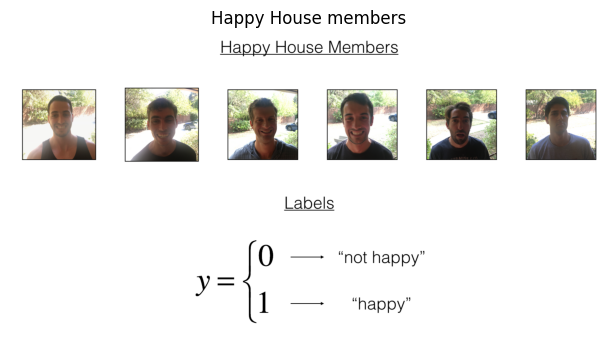

In [6]:
plt.figure(figsize=(8, 4))
plt.imshow(plt.imread(HOUSE_IMAGE_PATH))
plt.title("Happy House members")
plt.axis("off")
plt.show()

## Visual check of images

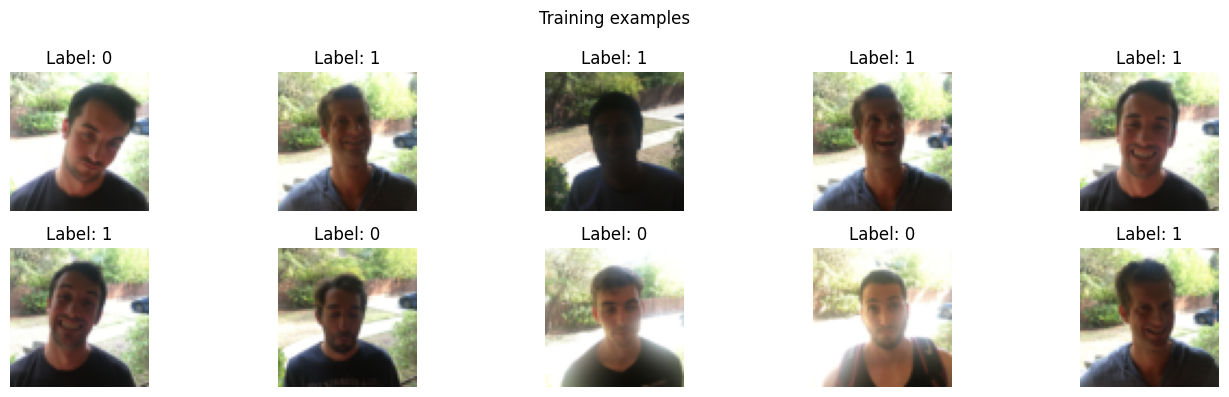

In [7]:
def plot_examples(images, labels, title, n_examples=10):
    plt.figure(figsize=(14, 4))
    for i in range(n_examples):
        ax = plt.subplot(2, 5, i + 1)
        ax.imshow(images[i])
        ax.set_title(f"Label: {int(labels[i, 0])}")
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_examples(X_train, Y_train, "Training examples")

## Build the CNN model

In [ ]:
def HappyModel(input_shape):
    """
    Implementation of the HappyModel.

    Arguments:
    input_shape -- shape of the images of the dataset

    Returns:
    model -- a Model() instance in Keras
    """

    X_input = Input(input_shape)

    X = ZeroPadding2D((3, 3))(X_input)

    X = Conv2D(32, (7, 7), strides=(1, 1), name="conv0")(X)
    X = BatchNormalization(axis=3, name="bn0")(X)
    X = Activation("relu")(X)

    X = MaxPooling2D((2, 2), name="max_pool")(X)

    X = Flatten()(X)
    X = Dense(1, activation="sigmoid", name="fc")(X)

    model = Model(inputs=X_input, outputs=X, name="HappyModel")

    return model

## Create the model

In [9]:
happyModel = HappyModel(X_train.shape[1:])
happyModel.summary()

Model: "HappyModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 70, 70, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv0 (Conv2D)                  │ (None, 64, 64, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn0 (BatchNormalization)        │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool (MaxPooling2D)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 64 (256.00 B)

## Compile the model

In [10]:
happyModel.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

## Train the model

In [11]:
history = happyModel.fit(
    x=X_train,
    y=Y_train,
    epochs=20,
    batch_size=100,
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.5033 - loss: 3.2351
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.6400 - loss: 0.9139
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.8133 - loss: 0.3611
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.8883 - loss: 0.2887
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.8867 - loss: 0.2693
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.8983 - loss: 0.2221
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9467 - loss: 0.1641
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.9500 - loss: 0.1326
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.9467 - loss: 0.1314
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.9600 - loss: 0.1137
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.9800 - loss: 0.0933
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.9800 - lo

## Training curves

In [12]:
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss
0,0.503333,3.235137
1,0.640000,0.913880
2,0.813333,0.361134
3,0.888333,0.288732
4,0.886667,0.269329


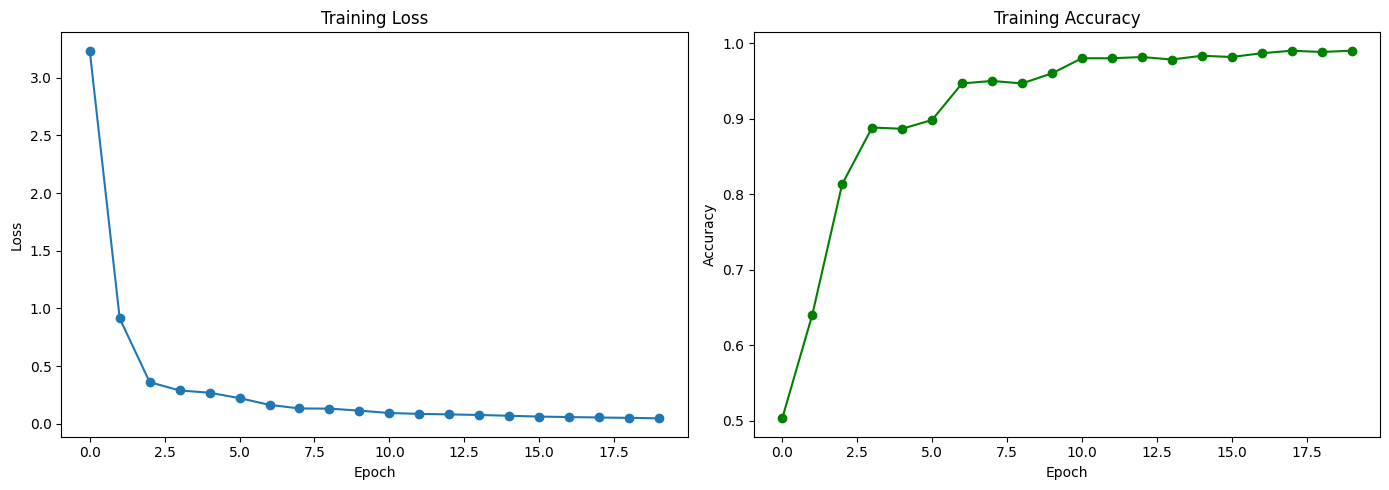

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history_df["accuracy"], marker="o", color="green")
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

## Evaluate the model

In [14]:
preds = happyModel.evaluate(x=X_test, y=Y_test)

print("Loss =", preds[0])
print("Test Accuracy =", preds[1])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9200 - loss: 0.3888 
Loss = 0.38882195949554443
Test Accuracy = 0.9200000166893005


## Prediction analysis

In [15]:
y_proba = happyModel.predict(X_test)
y_pred = (y_proba > 0.5).astype(int)

test_accuracy = (y_pred == Y_test).mean()
print("Manual test accuracy:", test_accuracy)

tn = int(((y_pred == 0) & (Y_test == 0)).sum())
fp = int(((y_pred == 1) & (Y_test == 0)).sum())
fn = int(((y_pred == 0) & (Y_test == 1)).sum())
tp = int(((y_pred == 1) & (Y_test == 1)).sum())

confusion_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

confusion_df

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Manual test accuracy: 0.92


,Predicted 0,Predicted 1
Actual 0,64,2
Actual 1,10,74


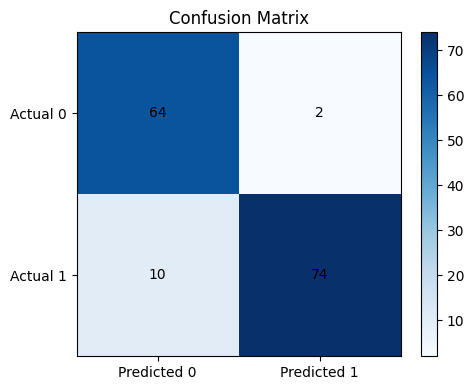

In [16]:
plt.figure(figsize=(5, 4))
plt.imshow(confusion_df.values, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0, 1], confusion_df.columns)
plt.yticks([0, 1], confusion_df.index)

for i in range(2):
    for j in range(2):
        plt.text(j, i, confusion_df.iloc[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

## Check several predictions

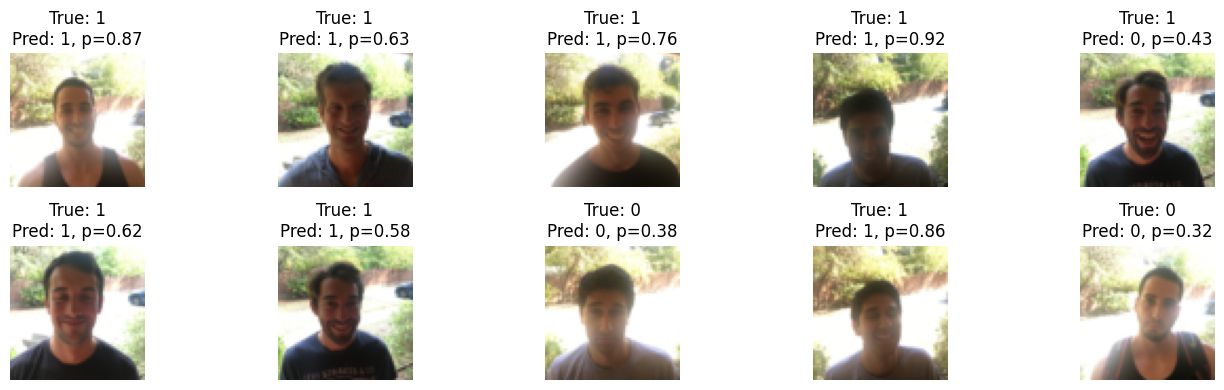

In [17]:
def plot_predictions(images, labels, predictions, probabilities, n_examples=10):
    plt.figure(figsize=(14, 4))
    for i in range(n_examples):
        ax = plt.subplot(2, 5, i + 1)
        ax.imshow(images[i])
        ax.set_title(
            f"True: {int(labels[i, 0])}\nPred: {int(predictions[i, 0])}, p={probabilities[i, 0]:.2f}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_predictions(X_test, Y_test, y_pred, y_proba)

## Final results

In [18]:
results_df = pd.DataFrame(
    [
        {
            "Model": "CNN HappyModel",
            "Epochs": 20,
            "Batch size": 100,
            "Loss": preds[0],
            "Test accuracy": preds[1],
        }
    ]
)

results_df

,Model,Epochs,Batch size,Loss,Test accuracy
0,CNN HappyModel,20,100,0.388822,0.92


## Conclusion

In this homework, I built a convolutional neural network for the Happy House binary image classification task.

The images were loaded from `.h5` files, normalized to the `[0, 1]` range, and passed into a Keras Functional API model. The CNN architecture uses zero padding, one convolutional block with batch normalization and ReLU activation, max pooling, flattening, and a final sigmoid output layer.

The model was trained for 20 epochs with batch size 100 and evaluated on the test dataset. The final test accuracy is much higher than random guessing, which means the CNN learned useful visual features for detecting happy faces.